# **Machine Learning Project 1**
## AI Detection Tools: Does the Model Learn Writing Style, or Just the Topic?
### Phillip Vogt

## Overview

Detecting AI generated text matters for academic integrity and content verification, and it is getting harder
as large language models get better at imitating human writing. The first version of this project trained
Naive Bayes and Logistic Regression on TF-IDF and stylometric features and reached 99% accuracy. The
conclusion was that the accuracy came mostly from topic bias rather than writing style, but that claim was
never tested directly.

**Research question: does a TF-IDF detector still work when it is tested on a topic it never trained on?
And how do model choice and feature type affect the answer?**

This revision keeps the original comparison and adds four things:

1. A topic holdout test. Essays are clustered into topics and the model is evaluated on a topic that was
   held out of training, which is the direct test of the topic bias claim.
2. A high dimensional model comparison. Logistic Regression, a neural network and a Random Forest are
   timed and scored on the same sparse 15,000 column TF-IDF matrix, plus a t-SNE view of the essay space.
3. Training on all 487,235 essays with a hashing vectorizer and chunked `partial_fit`, instead of a
   120,000 row sample.
4. A Linear SVM alongside Naive Bayes and Logistic Regression, and a closing summary printed from the
   values the notebook actually computed rather than typed by hand.

Data is the same [Kaggle set](https://www.kaggle.com/datasets/shanegerami/ai-vs-human-text) of roughly
500,000 essays labeled human or AI generated. Full run time is roughly 30 to 45 minutes on Colab with the
high RAM option.

### Imports
Standard data stack plus scikit-learn. Metrics are accuracy, macro F1 and ROC-AUC.

In [1]:
import os
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, HashingVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

### Configuration
Every sample size, split and seed used later. Lowering SAMPLE_SIZE, LOTO_SAMPLE and BENCH_SAMPLE is the way
to make the whole notebook run faster.

In [2]:
RANDOM_STATE = 42

SAMPLE_SIZE = 120_000
TEST_SIZE = 0.2
MAX_FEATURES = 15_000
NGRAM_RANGE = (1, 2)

N_TOPICS = 6
LOTO_SAMPLE = 60_000

BENCH_SAMPLE = 20_000
BENCH_TEST = 10_000
SVD_COMPONENTS = 300
TSNE_SAMPLE = 3_000

HASH_FEATURES = 2 ** 20
CHUNK_SIZE = 50_000
STREAM_TEST_SIZE = 40_000

np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (8, 5)

### Data path
Mounts Drive in Colab, otherwise reads DATA_PATH or a local file.

In [3]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_PATH = "/content/drive/MyDrive/Machine Learning/AI_Human.csv"
except ImportError:
    DATA_PATH = os.environ.get("DATA_PATH", "AI_Human.csv")

print("Reading data from:", DATA_PATH)

Mounted at /content/drive
Reading data from: /content/drive/MyDrive/Machine Learning/AI_Human.csv


### Load and clean
Renames the target, drops missing text, and reports the class balance of the full file.

In [4]:
df = pd.read_csv(DATA_PATH)
df = df.rename(columns={"generated": "label"})
df = df.dropna(subset=["text"])
df["label"] = df["label"].astype(int)

print("Rows:", f"{len(df):,}")
print("Columns:", list(df.columns))
print("\nClass balance (full file):")
print(df["label"].value_counts(normalize=True).round(4))

Rows: 487,235
Columns: ['text', 'label']

Class balance (full file):
label
0    0.6276
1    0.3724
Name: proportion, dtype: float64


### Sample and split
A stratified 120,000 essay sample keeps the comparison sections fast. The full file is used later in the
streaming section.

In [5]:
df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)
X = df_sample["text"]
y = df_sample["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set size: 96000
Test set size: 24000

Training label distribution:
label
0    0.627
1    0.373
Name: proportion, dtype: float64

Test label distribution:
label
0    0.627
1    0.373
Name: proportion, dtype: float64


## Exploratory Data Analysis

### Class balance and essay length
Class counts and the word count distribution for each class.

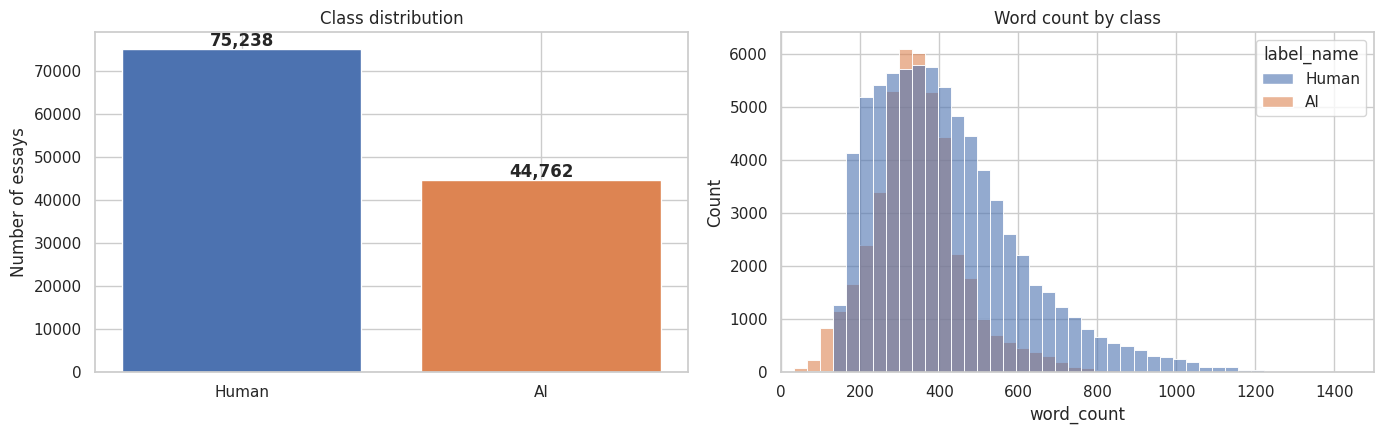


Word count statistics by class:
              count   mean    std   min    25%    50%    75%     max
label_name                                                          
AI          44762.0  344.9  116.4   0.0  274.0  337.0  403.0  1097.0
Human       75238.0  421.5  186.7  48.0  281.0  389.0  519.0  1651.0


In [6]:
df_sample["word_count"] = df_sample["text"].str.split().str.len()
df_sample["label_name"] = df_sample["label"].map({0: "Human", 1: "AI"})

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

counts = df_sample["label_name"].value_counts()
axes[0].bar(counts.index, counts.values, color=["#4C72B0", "#DD8452"])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Number of essays")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + len(df_sample) * 0.005, f"{v:,}", ha="center", fontweight="bold")

sns.histplot(data=df_sample, x="word_count", hue="label_name", bins=50, alpha=0.6, ax=axes[1])
axes[1].set_title("Word count by class")
axes[1].set_xlim(0, 1500)

plt.tight_layout()
plt.show()

print("\nWord count statistics by class:")
print(df_sample.groupby("label_name")["word_count"].describe().round(1))

Human essays run longer on average, with heavy overlap between the two distributions. Length alone cannot
separate the classes, but it can contribute as one feature.

## Feature Construction

Seven stylometric features describe how an essay is written rather than what it is about.

**num_words** total words, **avg_word_length** characters per word, **avg_sentence_length** words per
sentence, **num_exclamations** and **num_questions** punctuation counts, **num_uppercase** uppercase
characters, **lexical_diversity** unique words divided by total words.

In [7]:
def extract_features(text):
    text = str(text)
    words = text.split()
    sentences = [s for s in re.split(r"[.!?]+", text) if s.strip()]

    num_words = len(words)
    num_sentences = len(sentences) if sentences else 1
    avg_word_length = np.mean([len(w) for w in words]) if words else 0.0
    avg_sentence_length = num_words / num_sentences if num_sentences > 0 else 0.0
    unique_words = len(set(w.lower() for w in words))
    lexical_diversity = unique_words / num_words if num_words > 0 else 0.0

    return [num_words, avg_word_length, avg_sentence_length,
            text.count("!"), text.count("?"),
            sum(1 for c in text if c.isupper()), lexical_diversity]


STYLE_COLS = ["num_words", "avg_word_length", "avg_sentence_length",
              "num_exclamations", "num_questions", "num_uppercase", "lexical_diversity"]

X_train_style = np.array([extract_features(t) for t in X_train])
X_test_style = np.array([extract_features(t) for t in X_test])

print("Stylometric features (train):", X_train_style.shape)
print("Stylometric features (test): ", X_test_style.shape)

Stylometric features (train): (96000, 7)
Stylometric features (test):  (24000, 7)


### TF-IDF and the combined matrix
TF-IDF is fit on the training set only, with English stopwords removed, 15,000 features and unigrams plus
bigrams. Style features are scaled to 0-1 so Naive Bayes can accept them, then stacked onto TF-IDF.

In [8]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

scaler = MinMaxScaler()
X_train_style_scaled = scaler.fit_transform(X_train_style)
X_test_style_scaled = scaler.transform(X_test_style)

X_train_combined = hstack([X_train_tfidf, X_train_style_scaled]).tocsr()
X_test_combined = hstack([X_test_tfidf, X_test_style_scaled]).tocsr()

print("TF-IDF matrix: ", X_train_tfidf.shape)
print("Combined matrix:", X_train_combined.shape)
print("Sparsity of TF-IDF matrix:", f"{1 - X_train_tfidf.nnz / np.prod(X_train_tfidf.shape):.4%} zeros")

TF-IDF matrix:  (96000, 15000)
Combined matrix: (96000, 15007)
Sparsity of TF-IDF matrix: 99.0649% zeros


## Model Comparison

Six fits across three feature sets and three model families. Naive Bayes covers the three feature sets,
then Logistic Regression and a Linear SVM are run on the combined features to see whether the classifier
matters as much as the features.

In [9]:
def score_model(name, model, X_tr, y_tr, X_te, y_te):
    start = time.time()
    model.fit(X_tr, y_tr)
    fit_seconds = time.time() - start

    pred = model.predict(X_te)
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_te)[:, 1]
    else:
        scores = model.decision_function(X_te)

    return {"model": name,
            "accuracy": accuracy_score(y_te, pred),
            "macro_f1": f1_score(y_te, pred, average="macro"),
            "roc_auc": roc_auc_score(y_te, scores),
            "fit_seconds": fit_seconds}, model, pred

### Fit and score
Each entry trains one model and records accuracy, macro F1, ROC-AUC and fit time.

In [10]:
runs = [
    ("NB, TF-IDF only", MultinomialNB(), X_train_tfidf, X_test_tfidf),
    ("NB, style only", MultinomialNB(), X_train_style_scaled, X_test_style_scaled),
    ("NB, combined", MultinomialNB(), X_train_combined, X_test_combined),
    ("LR, TF-IDF only", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
     X_train_tfidf, X_test_tfidf),
    ("LR, combined", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
     X_train_combined, X_test_combined),
    ("Linear SVM, combined", LinearSVC(random_state=RANDOM_STATE),
     X_train_combined, X_test_combined),
]

results = []
fitted = {}
predictions = {}

for name, estimator, X_tr, X_te in runs:
    row, model, pred = score_model(name, estimator, X_tr, y_train, X_te, y_test)
    results.append(row)
    fitted[name] = model
    predictions[name] = pred
    print(f"{name:24s} accuracy {row['accuracy']:.4f}   roc_auc {row['roc_auc']:.4f}   "
          f"{row['fit_seconds']:.1f}s")

results_df = pd.DataFrame(results).set_index("model").round(4)
results_df

NB, TF-IDF only          accuracy 0.9637   roc_auc 0.9932   0.1s
NB, style only           accuracy 0.6270   roc_auc 0.7266   0.0s
NB, combined             accuracy 0.9640   roc_auc 0.9933   0.1s
LR, TF-IDF only          accuracy 0.9895   roc_auc 0.9991   6.4s
LR, combined             accuracy 0.9898   roc_auc 0.9990   3.4s
Linear SVM, combined     accuracy 0.9963   roc_auc 0.9998   2.8s


,accuracy,macro_f1,roc_auc,fit_seconds
model,,,,
"NB, TF-IDF only",0.9638,0.9611,0.9932,0.0801
"NB, style only",0.6270,0.3854,0.7266,0.0095
"NB, combined",0.9640,0.9614,0.9933,0.0820
"LR, TF-IDF only",0.9895,0.9887,0.9991,6.3935
"LR, combined",0.9898,0.9891,0.9990,3.3963
"Linear SVM, combined",0.9963,0.9961,0.9998,2.8459


### Accuracy comparison

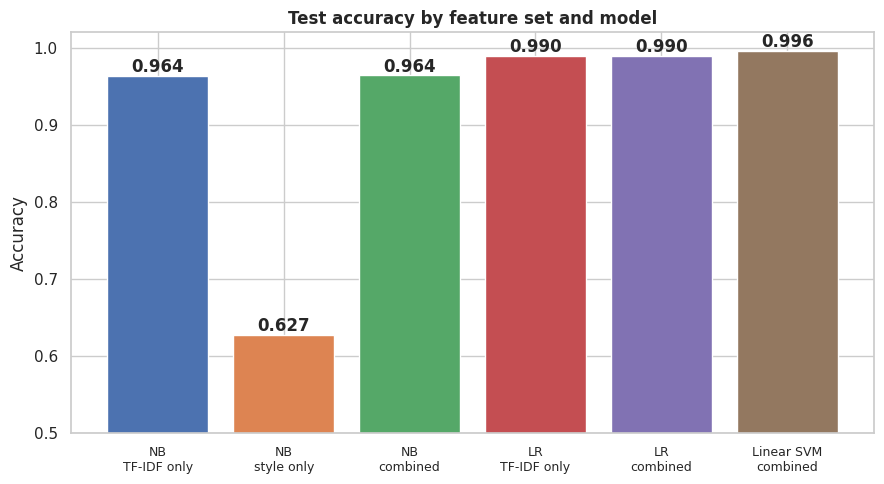

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(results_df)), results_df["accuracy"],
              color=sns.color_palette("deep", len(results_df)))
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels([m.replace(", ", "\n") for m in results_df.index], fontsize=9)
ax.set_ylabel("Accuracy")
ax.set_ylim(0.5, 1.02)
ax.set_title("Test accuracy by feature set and model", fontweight="bold")
for bar, acc in zip(bars, results_df["accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{acc:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### Best model detail
Classification report and confusion matrix for whichever model scored highest on accuracy.

Best model on the random split: Linear SVM, combined

              precision    recall  f1-score   support

       Human       1.00      1.00      1.00     15048
          AI       1.00      0.99      1.00      8952

    accuracy                           1.00     24000
   macro avg       1.00      1.00      1.00     24000
weighted avg       1.00      1.00      1.00     24000



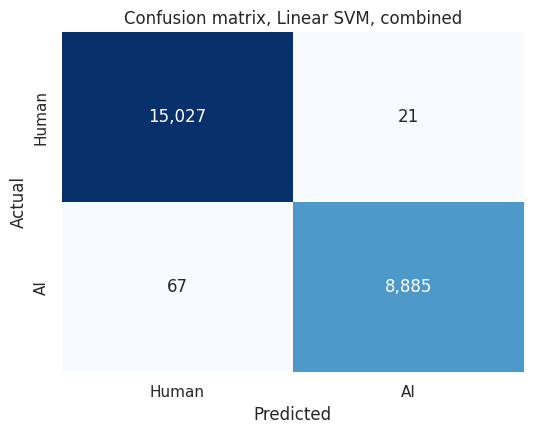

In [12]:
BEST_MODEL = results_df["accuracy"].idxmax()
best_pred = predictions[BEST_MODEL]

print(f"Best model on the random split: {BEST_MODEL}\n")
print(classification_report(y_test, best_pred, target_names=["Human", "AI"]))

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Human", "AI"], yticklabels=["Human", "AI"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix, {BEST_MODEL}")
plt.tight_layout()
plt.show()

### What the model is keying on
Top terms from the TF-IDF only models. Naive Bayes uses the log probability difference between classes,
Logistic Regression uses the fitted coefficients. These lists are stored and reused in the closing summary
so the written conclusion cannot drift from the output.

In [13]:
feature_names = vectorizer.get_feature_names_out()

nb_diff = fitted["NB, TF-IDF only"].feature_log_prob_[1] - fitted["NB, TF-IDF only"].feature_log_prob_[0]
lr_coef = fitted["LR, TF-IDF only"].coef_[0]

top_ai_terms = list(feature_names[np.argsort(nb_diff)[-15:]][::-1])
top_human_terms = list(feature_names[np.argsort(nb_diff)[:15]])
lr_ai_terms = list(feature_names[np.argsort(lr_coef)[-15:]][::-1])
lr_human_terms = list(feature_names[np.argsort(lr_coef)[:15]])

term_table = pd.DataFrame({
    "NB: AI": top_ai_terms,
    "NB: Human": top_human_terms,
    "LR: AI": lr_ai_terms,
    "LR: Human": lr_human_terms,
})
term_table

,NB: AI,NB: Human,LR: AI,LR: Human
0,university education,student_name,important,people
1,writing express,driveless,additionally,reason
2,like super,computer recognize,potential,driving
3,zoos,teacher_name,conclusion,going
4,tour guide,classroom computer,essay,percent
5,broad knowledge,sincerely student_name,provide,paragraph
6,support abolishing,everybody,super,voting
7,public health,good opportunity,hey,students
8,today express,text states,significant,nasa
9,personal growth,modify lesson,essential,said


Most of these are subject matter words rather than anything about how a sentence is built, which is the
first sign that the classifier is separating topics rather than styles. The holdout test below measures how
much of the accuracy that accounts for.

### Stylometric differences by class
Mean of each style feature by class, with the gap in absolute and percentage terms.

In [14]:
style_all = pd.DataFrame([extract_features(t) for t in df_sample["text"]], columns=STYLE_COLS)
style_all["label_name"] = df_sample["label_name"].values

style_comparison = style_all.groupby("label_name")[STYLE_COLS].mean().round(4).T
style_comparison["Difference"] = (style_comparison["AI"] - style_comparison["Human"]).round(4)
style_comparison["% Diff"] = (style_comparison["Difference"] / style_comparison["Human"] * 100).round(1)
style_comparison

label_name,AI,Human,Difference,% Diff
num_words,344.8940,421.5364,-76.6424,-18.2
avg_word_length,5.1264,4.5368,0.5896,13.0
avg_sentence_length,19.0637,21.3112,-2.2475,-10.5
num_exclamations,0.4236,0.2786,0.1450,52.0
num_questions,0.3342,0.8108,-0.4766,-58.8
num_uppercase,43.2793,55.3979,-12.1186,-21.9
lexical_diversity,0.5106,0.4808,0.0298,6.2


AI essays use longer words and a wider vocabulary, human essays run longer and carry more questions,
exclamations and uppercase characters. Real differences, but small enough that a model trained on them
alone stays close to the majority class rate.

## Topic Holdout Test

This is the section the first version was missing. If the detector works by recognizing essay subjects, it
should fall apart on a subject it has never seen.

Essays are clustered into topics with MiniBatchKMeans on TF-IDF. Clustering uses no labels, so it groups on
subject matter only. Each cluster is then held out in turn: the model trains on every other cluster and is
tested on the unseen one. The same model with the same test size is also run on a random split of the same
data, which is the only fair comparison since fold sizes and class ratios differ by topic.

### Cluster essays into topics
A fresh unigram TF-IDF is used for clustering, and the top centroid terms name each cluster.

In [15]:
loto = df_sample.sample(n=min(LOTO_SAMPLE, len(df_sample)), random_state=RANDOM_STATE).reset_index(drop=True)
loto_text = loto["text"]
loto_label = loto["label"]

cluster_vec = TfidfVectorizer(stop_words="english", max_features=MAX_FEATURES, ngram_range=(1, 1))
cluster_matrix = cluster_vec.fit_transform(loto_text)

kmeans = MiniBatchKMeans(n_clusters=N_TOPICS, random_state=RANDOM_STATE, n_init=5, batch_size=2048)
topics = kmeans.fit_predict(cluster_matrix)

cluster_terms = cluster_vec.get_feature_names_out()
topic_names = {}
for k in range(N_TOPICS):
    top_idx = kmeans.cluster_centers_[k].argsort()[-8:][::-1]
    topic_names[k] = ", ".join(cluster_terms[top_idx][:5])
    print(f"Topic {k}: {', '.join(cluster_terms[top_idx])}")

Topic 0: seagoing, cowboys, luke, program, animals, cowboy, join, fun
Topic 1: car, cars, driving, driverless, usage, limiting, people, transportation
Topic 2: face, mars, landform, aliens, natural, nasa, alien, picture
Topic 3: electoral, college, vote, president, states, votes, popular, election
Topic 4: students, school, student, people, help, like, time, work
Topic 5: venus, planet, author, earth, surface, exploring, studying, dangers


### Class composition of each topic
If human and AI essays covered the same subjects, every topic would sit near the overall AI share.

In [16]:
composition = pd.DataFrame({"topic": topics, "label": loto_label.values})
topic_table = composition.groupby("topic")["label"].agg(n_essays="size", ai_share="mean").round(4)
topic_table["top_terms"] = [topic_names[k] for k in topic_table.index]
topic_table["base_rate_gap"] = (topic_table["ai_share"] - loto_label.mean()).round(4)

print("Overall AI share:", round(loto_label.mean(), 4))
topic_table

Overall AI share: 0.3735


,n_essays,ai_share,top_terms,base_rate_gap
topic,,,,
0,2180,0.1945,"seagoing, cowboys, luke, program, animals",-0.1790
1,10828,0.2609,"car, cars, driving, driverless, usage",-0.1126
2,3005,0.2353,"face, mars, landform, aliens, natural",-0.1382
3,6531,0.3335,"electoral, college, vote, president, states",-0.0400
4,34403,0.4559,"students, school, student, people, help",0.0824
5,3053,0.1936,"venus, planet, author, earth, surface",-0.1799


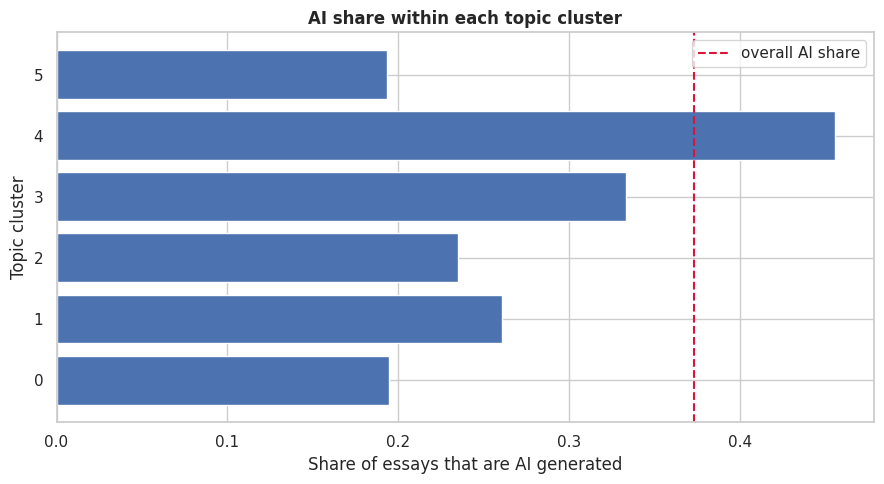

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(topic_table.index.astype(str), topic_table["ai_share"], color="#4C72B0")
ax.axvline(loto_label.mean(), color="crimson", linestyle="--", label="overall AI share")
ax.set_xlabel("Share of essays that are AI generated")
ax.set_ylabel("Topic cluster")
ax.set_title("AI share within each topic cluster", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

The further these bars sit from the red line, the more a model can score simply by learning which subjects
belong to which class.

### Leave one topic out
For each topic, TF-IDF is refit on the training topics only and Logistic Regression is scored on the unseen
topic. The random baseline repeats the identical fit on a random subset of the same size.

In [18]:
def fit_and_score(train_text, train_label, test_text, test_label):
    vec = TfidfVectorizer(stop_words="english", max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)
    X_tr = vec.fit_transform(train_text)
    X_te = vec.transform(test_text)

    clf = LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE)
    clf.fit(X_tr, train_label)

    pred = clf.predict(X_te)
    proba = clf.predict_proba(X_te)[:, 1]
    return {"acc": accuracy_score(test_label, pred),
            "bal_acc": balanced_accuracy_score(test_label, pred),
            "auc": roc_auc_score(test_label, proba)}


loto_rows = []
for k in range(N_TOPICS):
    held_out = topics == k
    if loto_label[held_out].nunique() < 2 or held_out.sum() < 100:
        print(f"Topic {k} skipped, not enough of both classes in the fold")
        continue

    topic_scores = fit_and_score(
        loto_text[~held_out], loto_label[~held_out], loto_text[held_out], loto_label[held_out])

    rng = np.random.RandomState(RANDOM_STATE + k)
    random_mask = np.zeros(len(loto_text), dtype=bool)
    random_mask[rng.permutation(len(loto_text))[:held_out.sum()]] = True
    random_scores = fit_and_score(
        loto_text[~random_mask], loto_label[~random_mask],
        loto_text[random_mask], loto_label[random_mask])

    majority = max(loto_label[held_out].mean(), 1 - loto_label[held_out].mean())

    loto_rows.append({"topic": k, "top_terms": topic_names[k], "n_test": int(held_out.sum()),
                      "ai_share": round(loto_label[held_out].mean(), 4),
                      "majority_baseline": round(majority, 4),
                      "topic_acc": topic_scores["acc"], "topic_bal_acc": topic_scores["bal_acc"],
                      "topic_auc": topic_scores["auc"],
                      "random_acc": random_scores["acc"], "random_bal_acc": random_scores["bal_acc"],
                      "random_auc": random_scores["auc"]})
    print(f"Topic {k}: unseen topic roc_auc {topic_scores['auc']:.4f} "
          f"vs random split {random_scores['auc']:.4f}")

loto_df = pd.DataFrame(loto_rows).set_index("topic").round(4)
loto_df

Topic 0: unseen topic roc_auc 0.9855 vs random split 0.9991
Topic 1: unseen topic roc_auc 0.9963 vs random split 0.9987
Topic 2: unseen topic roc_auc 0.9927 vs random split 0.9996
Topic 3: unseen topic roc_auc 0.9902 vs random split 0.9990
Topic 4: unseen topic roc_auc 0.9097 vs random split 0.9981
Topic 5: unseen topic roc_auc 0.9910 vs random split 0.9990


,top_terms,n_test,ai_share,majority_baseline,topic_acc,topic_bal_acc,topic_auc,random_acc,random_bal_acc,random_auc
topic,,,,,,,,,,
0,"seagoing, cowboys, luke, program, animals",2180,0.1945,0.8055,0.9353,0.9312,0.9855,0.9853,0.9829,0.9991
1,"car, cars, driving, driverless, usage",10828,0.2609,0.7391,0.9668,0.9373,0.9963,0.9862,0.9837,0.9987
2,"face, mars, landform, aliens, natural",3005,0.2353,0.7647,0.9398,0.8730,0.9927,0.9920,0.9904,0.9996
3,"electoral, college, vote, president, states",6531,0.3335,0.6665,0.8547,0.7821,0.9902,0.9878,0.9853,0.9990
4,"students, school, student, people, help",34403,0.4559,0.5441,0.6948,0.6655,0.9097,0.9852,0.9825,0.9981
5,"venus, planet, author, earth, surface",3053,0.1936,0.8064,0.9129,0.7762,0.9910,0.9879,0.9857,0.9990


### Holdout versus random split
Mean across topics, and the same numbers as a chart.

                   random split  unseen topic  difference
accuracy                 0.9874        0.8840      0.1034
balanced_accuracy        0.9851        0.8276      0.1575
roc_auc                  0.9989        0.9776      0.0214


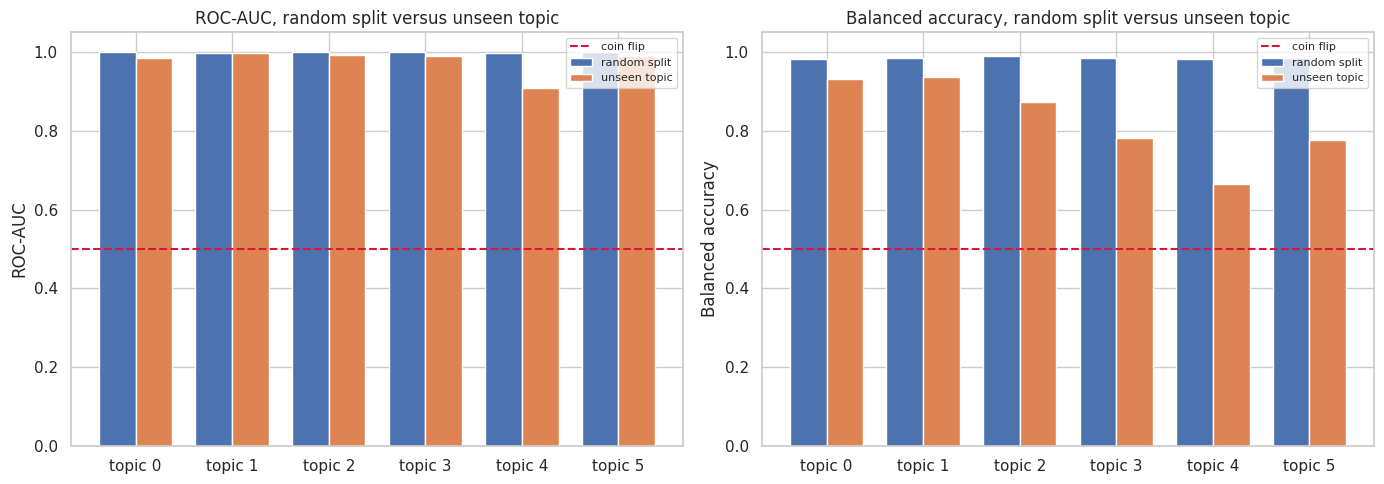

In [19]:
TOPIC_ACC = loto_df["topic_acc"].mean()
RANDOM_ACC = loto_df["random_acc"].mean()
TOPIC_BAL = loto_df["topic_bal_acc"].mean()
RANDOM_BAL = loto_df["random_bal_acc"].mean()
TOPIC_AUC = loto_df["topic_auc"].mean()
RANDOM_AUC = loto_df["random_auc"].mean()
AUC_DROP = RANDOM_AUC - TOPIC_AUC
ACC_DROP = RANDOM_ACC - TOPIC_ACC

summary = pd.DataFrame({
    "random split": [RANDOM_ACC, RANDOM_BAL, RANDOM_AUC],
    "unseen topic": [TOPIC_ACC, TOPIC_BAL, TOPIC_AUC],
    "difference": [ACC_DROP, RANDOM_BAL - TOPIC_BAL, AUC_DROP],
}, index=["accuracy", "balanced_accuracy", "roc_auc"]).round(4)

print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
width = 0.38
positions = np.arange(len(loto_df))

axes[0].bar(positions - width / 2, loto_df["random_auc"], width, label="random split", color="#4C72B0")
axes[0].bar(positions + width / 2, loto_df["topic_auc"], width, label="unseen topic", color="#DD8452")
axes[0].axhline(0.5, color="crimson", linestyle="--", label="coin flip")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("ROC-AUC, random split versus unseen topic")

axes[1].bar(positions - width / 2, loto_df["random_bal_acc"], width, label="random split", color="#4C72B0")
axes[1].bar(positions + width / 2, loto_df["topic_bal_acc"], width, label="unseen topic", color="#DD8452")
axes[1].axhline(0.5, color="crimson", linestyle="--", label="coin flip")
axes[1].set_ylabel("Balanced accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Balanced accuracy, random split versus unseen topic")

for ax in axes:
    ax.set_xticks(positions)
    ax.set_xticklabels([f"topic {k}" for k in loto_df.index])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Plain accuracy is not trustworthy on these folds, because a topic that is almost entirely one class can be
scored well by a model that always guesses that class. ROC-AUC and balanced accuracy correct for that, and
an AUC near 0.5 means the model has no usable signal on the unseen topic. The gap between the blue and
orange bars is the part of the random split score that came from topic familiarity rather than from
anything about AI writing.

## High Dimensional Behavior

The TF-IDF matrix is 15,000 columns and about 99% zeros. This section compares three model families on that
same matrix, measures what dimension reduction does to the Random Forest, and looks at the essay space
directly.

### Model families on a sparse matrix
Logistic Regression, a small neural network and a Random Forest on identical features, timed.

In [20]:
rng = np.random.RandomState(RANDOM_STATE)
bench_train_idx = rng.choice(X_train_tfidf.shape[0], min(BENCH_SAMPLE, X_train_tfidf.shape[0]), replace=False)
bench_test_idx = rng.choice(X_test_tfidf.shape[0], min(BENCH_TEST, X_test_tfidf.shape[0]), replace=False)

Xb_train = X_train_tfidf[bench_train_idx]
yb_train = y_train.iloc[bench_train_idx]
Xb_test = X_test_tfidf[bench_test_idx]
yb_test = y_test.iloc[bench_test_idx]

bench_models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("Neural network (64)", MLPClassifier(hidden_layer_sizes=(64,), early_stopping=True,
                                          max_iter=30, random_state=RANDOM_STATE)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, min_samples_leaf=2,
                                             n_jobs=-1, random_state=RANDOM_STATE)),
]

bench_rows = []
for name, model in bench_models:
    row, _, _ = score_model(f"{name}, sparse TF-IDF", model, Xb_train, yb_train, Xb_test, yb_test)
    bench_rows.append(row)
    print(f"{name:22s} accuracy {row['accuracy']:.4f}   {row['fit_seconds']:.1f}s")

Logistic Regression    accuracy 0.9816   5.0s
Neural network (64)    accuracy 0.9907   51.3s
Random Forest          accuracy 0.9769   3.5s


### The same Random Forest after dimension reduction
TruncatedSVD compresses the 15,000 sparse columns into a few hundred dense components, which is the setting
a tree model can actually split on.

In [21]:
svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
Xb_train_svd = svd.fit_transform(Xb_train)
Xb_test_svd = svd.transform(Xb_test)

row, _, _ = score_model(f"Random Forest, SVD {SVD_COMPONENTS}",
                        RandomForestClassifier(n_estimators=100, min_samples_leaf=2,
                                               n_jobs=-1, random_state=RANDOM_STATE),
                        Xb_train_svd, yb_train, Xb_test_svd, yb_test)
bench_rows.append(row)

bench_df = pd.DataFrame(bench_rows).set_index("model").round(4)
print(f"Variance kept by {SVD_COMPONENTS} components: {svd.explained_variance_ratio_.sum():.2%}")
bench_df

Variance kept by 300 components: 43.78%


,accuracy,macro_f1,roc_auc,fit_seconds
model,,,,
"Logistic Regression, sparse TF-IDF",0.9816,0.9802,0.9972,5.0497
"Neural network (64), sparse TF-IDF",0.9907,0.9900,0.9989,51.2541
"Random Forest, sparse TF-IDF",0.9769,0.9750,0.9968,3.4886
"Random Forest, SVD 300",0.9670,0.9644,0.9933,8.2575


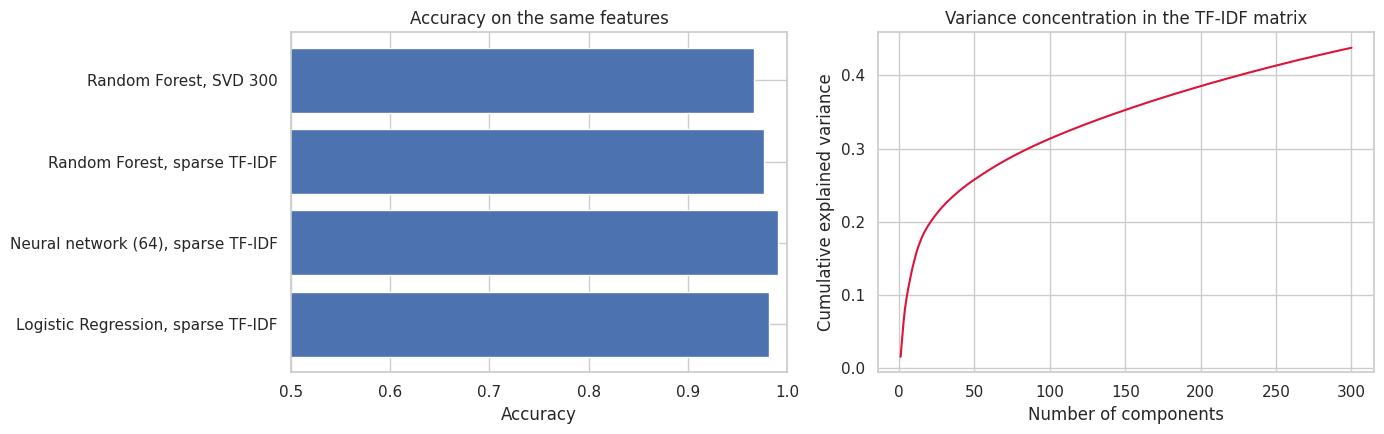

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].barh(bench_df.index, bench_df["accuracy"], color="#4C72B0")
axes[0].set_xlim(0.5, 1.0)
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Accuracy on the same features")

axes[1].plot(np.arange(1, SVD_COMPONENTS + 1), np.cumsum(svd.explained_variance_ratio_), color="crimson")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Variance concentration in the TF-IDF matrix")

plt.tight_layout()
plt.show()

The variance curve shows how little of the total variance the leading components hold, which is the reason
a Random Forest struggles here. With 15,000 mostly zero columns, a randomly chosen split candidate is
almost always uninformative, while a linear model can use all columns at once.

### t-SNE of the essay space
SVD to 50 components first, then t-SNE on a 3,000 essay subsample, colored by class and by topic cluster.

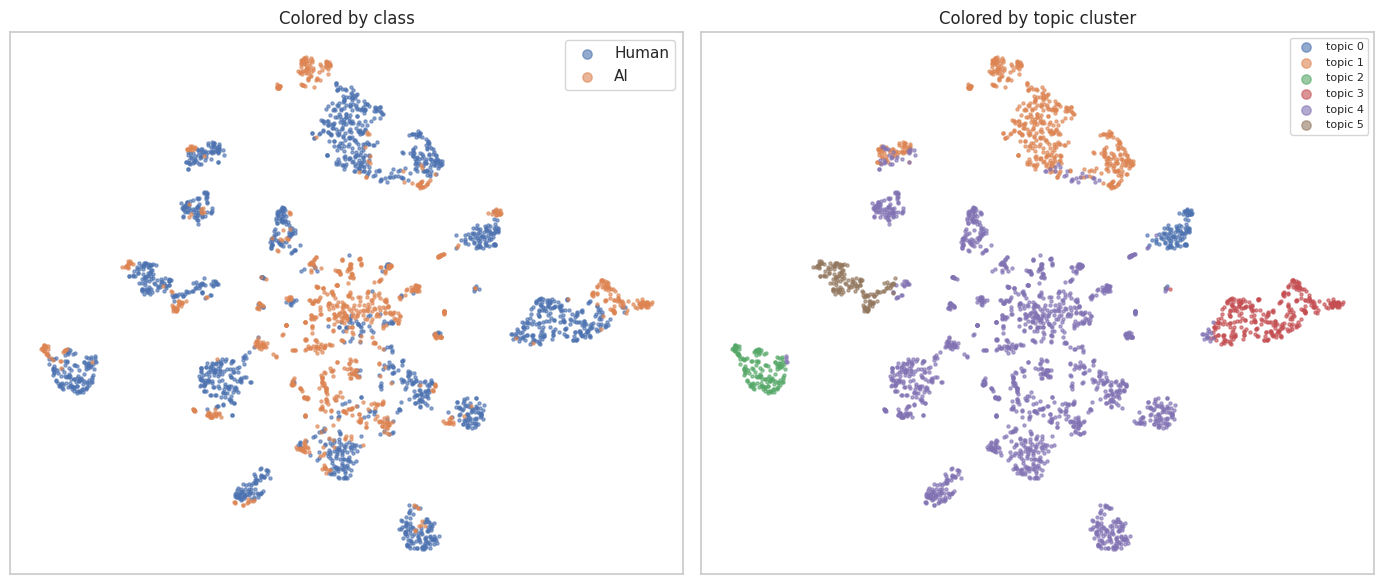

In [23]:
tsne_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(loto_text), min(TSNE_SAMPLE, len(loto_text)), replace=False)

tsne_input = TruncatedSVD(n_components=50, random_state=RANDOM_STATE).fit_transform(cluster_matrix[tsne_idx])
embedding = TSNE(n_components=2, init="pca", perplexity=30,
                 random_state=RANDOM_STATE).fit_transform(tsne_input)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
label_subset = loto_label.values[tsne_idx]
topic_subset = topics[tsne_idx]

for value, name, color in [(0, "Human", "#4C72B0"), (1, "AI", "#DD8452")]:
    mask = label_subset == value
    axes[0].scatter(embedding[mask, 0], embedding[mask, 1], s=5, alpha=0.6, c=color, label=name)
axes[0].set_title("Colored by class")
axes[0].legend(markerscale=3)

palette = sns.color_palette("deep", N_TOPICS)
for k in range(N_TOPICS):
    mask = topic_subset == k
    axes[1].scatter(embedding[mask, 0], embedding[mask, 1], s=5, alpha=0.6,
                    color=palette[k], label=f"topic {k}")
axes[1].set_title("Colored by topic cluster")
axes[1].legend(markerscale=3, fontsize=8)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

If the same blobs that separate the classes also separate the topics, the two signals are entangled and the
class boundary is partly a topic boundary.

## Training on the Full 487,235 Essays

The sections above use a 120,000 essay sample so they finish quickly. This section uses everything. A
HashingVectorizer maps terms into a fixed 1,048,576 column space with no vocabulary to hold in memory, and
SGDClassifier learns through `partial_fit` on one chunk at a time. The same loop works unchanged on a file
too large to load by reading it with `pd.read_csv(..., chunksize=CHUNK_SIZE)`.

### Stream the full dataset
The index is shuffled first so each chunk carries both classes, a held-out slice is set aside, and test
accuracy is recorded after every chunk.

In [24]:
hashing = HashingVectorizer(n_features=HASH_FEATURES, stop_words="english",
                            ngram_range=NGRAM_RANGE, alternate_sign=False, norm="l2")

order = np.random.RandomState(RANDOM_STATE).permutation(len(df))
test_positions = order[:STREAM_TEST_SIZE]
train_positions = order[STREAM_TEST_SIZE:]

stream_test = df.iloc[test_positions]
X_stream_test = hashing.transform(stream_test["text"])
y_stream_test = stream_test["label"].values

sgd = SGDClassifier(loss="log_loss", random_state=RANDOM_STATE)
history = []
start = time.time()

for position in range(0, len(train_positions), CHUNK_SIZE):
    chunk = df.iloc[train_positions[position:position + CHUNK_SIZE]]
    sgd.partial_fit(hashing.transform(chunk["text"]), chunk["label"].values, classes=np.array([0, 1]))
    seen = position + len(chunk)
    history.append({"essays_seen": seen,
                    "test_accuracy": accuracy_score(y_stream_test, sgd.predict(X_stream_test))})
    print(f"{seen:>7,} essays seen   test accuracy {history[-1]['test_accuracy']:.4f}")

STREAM_SECONDS = time.time() - start
history_df = pd.DataFrame(history)
FULL_DATA_ACC = history_df["test_accuracy"].iloc[-1]
FULL_DATA_AUC = roc_auc_score(y_stream_test, sgd.predict_proba(X_stream_test)[:, 1])

print(f"\nTrained on {len(train_positions):,} essays in {STREAM_SECONDS:.1f}s")
print(f"Final accuracy {FULL_DATA_ACC:.4f}, ROC-AUC {FULL_DATA_AUC:.4f}")

 50,000 essays seen   test accuracy 0.9725
100,000 essays seen   test accuracy 0.9726
150,000 essays seen   test accuracy 0.9717
200,000 essays seen   test accuracy 0.9728
250,000 essays seen   test accuracy 0.9735
300,000 essays seen   test accuracy 0.9733
350,000 essays seen   test accuracy 0.9738
400,000 essays seen   test accuracy 0.9729
447,235 essays seen   test accuracy 0.9730

Trained on 447,235 essays in 150.2s
Final accuracy 0.9730, ROC-AUC 0.9948


### Learning curve
Test accuracy against the number of essays the model has seen.

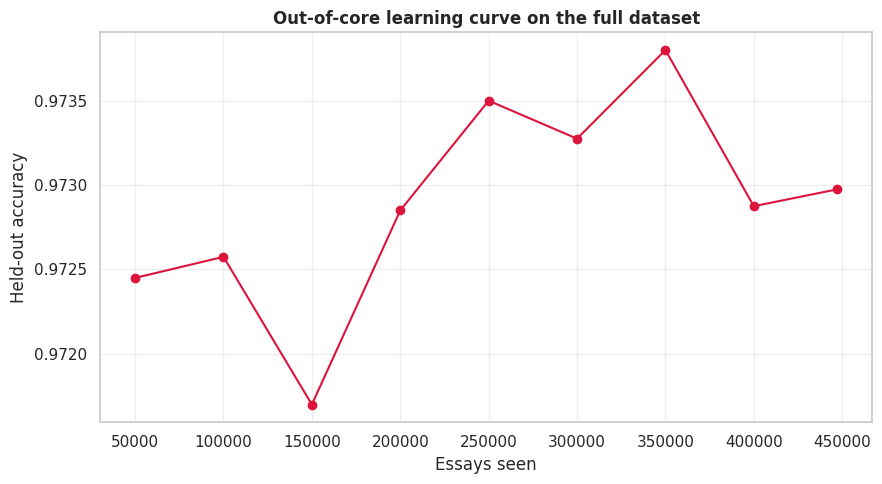

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_df["essays_seen"], history_df["test_accuracy"], marker="o", color="crimson")
ax.set_xlabel("Essays seen")
ax.set_ylabel("Held-out accuracy")
ax.set_title("Out-of-core learning curve on the full dataset", fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The curve flattens well before the last chunk, so the extra 367,000 essays buy very little over the 120,000
sample. That is worth knowing before paying for compute on the whole file.

## Conclusion

The summary below is printed from the variables this notebook computed, so the written claims stay tied to
the output.

In [26]:
print("AI GENERATED TEXT DETECTION, SUMMARY")
print("=" * 70)
print(f"Sample used for the model comparison: {len(df_sample):,} essays")
print(f"Full dataset used for streaming:      {len(df):,} essays")
print()
print("Random split, held-out test set:")
for name in results_df.index:
    print(f"  {name:24s} accuracy {results_df.loc[name, 'accuracy']:.4f}   "
          f"roc_auc {results_df.loc[name, 'roc_auc']:.4f}")
print()
print(f"Best on the random split: {BEST_MODEL} at {results_df['accuracy'].max():.4f}")
print(f"Style features alone:     {results_df.loc['NB, style only', 'accuracy']:.4f}")
print()
print("Topic holdout test, averaged over topics:")
print(f"  roc_auc             random split {RANDOM_AUC:.4f}   unseen topic {TOPIC_AUC:.4f}   "
      f"drop {AUC_DROP:.4f}")
print(f"  balanced accuracy   random split {RANDOM_BAL:.4f}   unseen topic {TOPIC_BAL:.4f}   "
      f"drop {RANDOM_BAL - TOPIC_BAL:.4f}")
print(f"  raw accuracy        random split {RANDOM_ACC:.4f}   unseen topic {TOPIC_ACC:.4f}")
print()
print("High dimensional comparison on identical sparse features:")
for name in bench_df.index:
    print(f"  {name:28s} accuracy {bench_df.loc[name, 'accuracy']:.4f}   "
          f"{bench_df.loc[name, 'fit_seconds']:.1f}s")
print()
print(f"Full dataset, hashing plus SGD: accuracy {FULL_DATA_ACC:.4f}, roc_auc {FULL_DATA_AUC:.4f}, "
      f"{STREAM_SECONDS:.0f}s")
print()
print("Terms most associated with AI text:   " + ", ".join(top_ai_terms[:8]))
print("Terms most associated with human text: " + ", ".join(top_human_terms[:8]))
print("=" * 70)

AI GENERATED TEXT DETECTION, SUMMARY
Sample used for the model comparison: 120,000 essays
Full dataset used for streaming:      487,235 essays

Random split, held-out test set:
  NB, TF-IDF only          accuracy 0.9638   roc_auc 0.9932
  NB, style only           accuracy 0.6270   roc_auc 0.7266
  NB, combined             accuracy 0.9640   roc_auc 0.9933
  LR, TF-IDF only          accuracy 0.9895   roc_auc 0.9991
  LR, combined             accuracy 0.9898   roc_auc 0.9990
  Linear SVM, combined     accuracy 0.9963   roc_auc 0.9998

Best on the random split: Linear SVM, combined at 0.9963
Style features alone:     0.6270

Topic holdout test, averaged over topics:
  roc_auc             random split 0.9989   unseen topic 0.9776   drop 0.0214
  balanced accuracy   random split 0.9851   unseen topic 0.8276   drop 0.1575
  raw accuracy        random split 0.9874   unseen topic 0.8840

High dimensional comparison on identical sparse features:
  Logistic Regression, sparse TF-IDF accuracy 0.98

### What this shows

The headline accuracy on a random split is very high, and almost all of it comes from word content. Style
features on their own land near the majority class rate, and adding them to TF-IDF changes little. The
classifier choice matters as much as the feature set, with the linear models well ahead of Naive Bayes on
the same inputs.

The topic holdout is the result that matters. When a subject is removed from training entirely, ROC-AUC
falls to the level printed above, and the closer that number sits to 0.5 the more of the random split score
was topic familiarity rather than a durable signal about how AI writes. The term tables point the same
direction, since the strongest features are subject words rather than anything structural.

The high dimensional section explains why the linear models win. The TF-IDF matrix is wide and almost
entirely zeros, so a Random Forest rarely draws an informative split candidate, and reducing to a few
hundred dense components changes its behavior noticeably. The learning curve on the full 487,235 essays
flattens early, so the sample was never the limiting factor. The limiting factor is that the dataset pairs
each class with its own subjects.

### Where this goes next

1. Rebuild the dataset so both classes cover an identical set of prompts, then rerun the same comparison.
   Any accuracy that survives is style signal.
2. Expand the style feature set with readability scores, transition word density, passive voice rate and
   paragraph structure, then rerun the topic holdout on style features only, where topic bias cannot help.
3. Test transfer to other kinds of writing such as emails, news and forum posts, where the topic mix looks
   nothing like student essays.
4. Compare outputs from different models to see whether each leaves its own detectable fingerprint.